# RQ2: Trigger dei workflow (on: push, on: pull_request, on: schedule...) — capire come questi sistemi AI vengono integrati e testati e in quali step di workflow

##### nb: Sostanzialmente estraendo questi dati e prendendo le top keywords, vogliamo capire QUANDO i workflows vengono triggerati in queste repositories.

In [4]:
import pandas as pd

DATASET_PATH = "D:\\sgpv\\SE4AI-base\\gigawork\\dataset_with_ids.csv"
BASE_GIGAWORK_PATH = "D:\\sgpv\\SE4AI-base\\gigawork\\all_workflows"
LABELLED_DATASET_PATH = "D:\\sgpv\\SE4AI-base\\gigawork\\extracted_workflow_types.csv"
PARTIAL_CLAUDE_LABELLED_DATASET_PATH = "D:\\sgpv\\SE4AI-base\\gigawork\\first_100_extracted_workflow_types_with_llm_labels_claude.csv"

#df = pd.read_csv(DATASET_PATH)

In [26]:
repositories = df.groupby("repository")

# per ogni repository prendiamo tutti i file hash associati allo stesso file hash, se il file è stato eliminato prendiamo l'ultimo.
tmp = df.dropna(subset=["repository", "workflow_global_id"]).copy()

# timestamp per prendere l'ultima modifica effettuata al file
tmp["event_ts"] = pd.to_numeric(tmp["committed_date"], errors="coerce")
tmp["event_ts"] = tmp["event_ts"].fillna(pd.to_numeric(tmp["authored_date"], errors="coerce"))
tmp["file_h"] = tmp["file_hash"].fillna(tmp["previous_file_hash"])

last_file = (
    tmp.sort_values(["repository", "workflow_global_id", "event_ts"])
       .groupby(["repository", "workflow_global_id"], as_index=False)
       .tail(1)
       .reset_index(drop=True)
)
repo_summary = (
    last_file.groupby("repository", as_index=False)
    .agg(
        files=("file_h", lambda s: [x for x in s.dropna().unique()]),
    )
    .reset_index(drop=True)
)

In [27]:
import yaml
from pathlib import Path
from collections import Counter


def get_on_section(workflow_dict):
    """Ritorna il contenuto della chiave `on`, gestendo anche il parsing YAML 1.1 (`on` -> True)."""
    if not isinstance(workflow_dict, dict):
        return None

    if "on" in workflow_dict:
        return workflow_dict["on"]

    # In PyYAML, la chiave `on` non quotata puo essere interpretata come boolean True.
    if True in workflow_dict:
        return workflow_dict[True]

    for k, v in workflow_dict.items():
        if isinstance(k, str) and k.strip().lower() == "on":
            return v

    return None


def extract_triggers(on_value):
    """Estrae i trigger principali dal campo `on` di una workflow GitHub Actions."""
    if on_value is None:
        return []

    if isinstance(on_value, str):
        return [on_value.strip()] if on_value.strip() else []

    if isinstance(on_value, list):
        triggers = []
        for item in on_value:
            if isinstance(item, str) and item.strip():
                triggers.append(item.strip())
            elif isinstance(item, dict):
                triggers.extend([str(k).strip() for k in item.keys() if str(k).strip()])
        return sorted(set(triggers))

    if isinstance(on_value, dict):
        return sorted({str(k).strip() for k in on_value.keys() if str(k).strip()})

    return []


stats_per_repo = {}
total_trigger_counter = Counter()
total_trigger_counter_unique = Counter()

for repo in repo_summary["repository"].unique():
    files = repo_summary.loc[repo_summary["repository"] == repo, "files"].values[0]
    repo_triggers = Counter()

    for file in files:
        path = Path(BASE_GIGAWORK_PATH) / repo / file
        try:
            with open(path, "r", encoding="utf-8") as f:
                data = yaml.safe_load(f)
        except Exception:
            continue

        on_section = get_on_section(data)
        triggers = extract_triggers(on_section)

        if not triggers:
            continue

        repo_triggers.update(triggers)
        total_trigger_counter.update(triggers)
        total_trigger_counter_unique.update(set(triggers))

    stats_per_repo[repo] = dict(repo_triggers)

print("Top trigger totali:", total_trigger_counter.most_common(20))
print("Top trigger unici per file:", total_trigger_counter_unique.most_common(20))

# calcolo in percentuale quanto è diffusa ogni trigger rispetto al totale
total_files_with_trigger = sum(total_trigger_counter_unique.values())

trigger_percentage_df = pd.DataFrame(
[
    {
        "trigger": trigger,
        "percentage": (count / total_files_with_trigger) * 100 if total_files_with_trigger else 0.0,
    }
    for trigger, count in total_trigger_counter_unique.items()
]
).sort_values(["percentage", "trigger"]).reset_index(drop=True)

print(trigger_percentage_df)




Top trigger totali: [('push', 307), ('pull_request', 280), ('workflow_dispatch', 213), ('schedule', 74), ('workflow_call', 55), ('pull_request_target', 51), ('release', 39), ('issues', 19), ('workflow_run', 18), ('issue_comment', 17), ('merge_group', 16), ('pull_request_review', 8), ('repository_dispatch', 5), ('pull_request_review_comment', 5), ('branch_protection_rule', 2), ('delete', 1)]
Top trigger unici per file: [('push', 307), ('pull_request', 280), ('workflow_dispatch', 213), ('schedule', 74), ('workflow_call', 55), ('pull_request_target', 51), ('release', 39), ('issues', 19), ('workflow_run', 18), ('issue_comment', 17), ('merge_group', 16), ('pull_request_review', 8), ('repository_dispatch', 5), ('pull_request_review_comment', 5), ('branch_protection_rule', 2), ('delete', 1)]
                        trigger  percentage
0                        delete    0.090090
1        branch_protection_rule    0.180180
2   pull_request_review_comment    0.450450
3           repository_dispa

Grafici

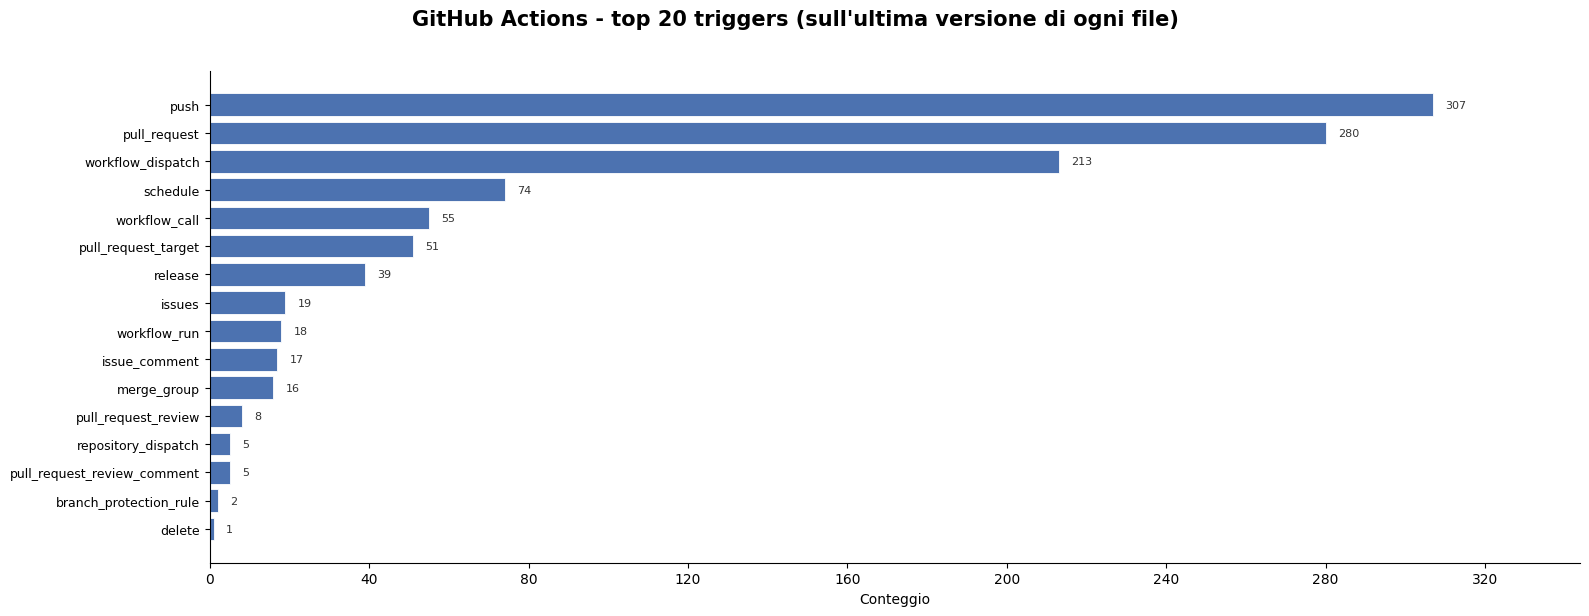

In [28]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

TOP_N = 20

top_total = total_trigger_counter_unique.most_common(TOP_N)

labels_total, values_total = zip(*top_total)

fig, ax = plt.subplots(figsize=(16, 6))
fig.suptitle(f"GitHub Actions - top {TOP_N} triggers (sull'ultima versione di ogni file)", fontsize=15, fontweight="bold", y=1.02)

def bar_chart(ax, labels, values, color):
    bars = ax.barh(labels[::-1], values[::-1], color=color, edgecolor="white", linewidth=0.6)
    ax.set_xlabel("Conteggio", fontsize=10)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=9)
    for bar, val in zip(bars, values[::-1]):
        ax.text(
            bar.get_width() + max(values) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            str(val),
            va="center", ha="left", fontsize=8, color="#333"
        )
    ax.set_xlim(0, max(values) * 1.12)

bar_chart(
    ax, labels_total, values_total,
    "#4C72B0"
)

plt.tight_layout()
# plt.savefig("triggers_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**possiamo dedurre che:** per più del 50% del totale, se un workflow viene triggerato è perchè è stata rilevata una azione di push o pull request.

una fetta importante è occupata da workflow_dispatch, che occupa il 20% del totale. Workflow dispatch indica che l'azione del workflow è stata avviata a mano.

al quarto posto con circa il 9% abbiamo schedule, il che indica che alcune repositories hanno delle azioni ricorrenti.

successivamente andremo ad analizzare quali sono le azioni più effettuate durante ciascuno dei trigger, in modo da capire meglio cosa viene effettuato e quando.

In [29]:
from collections import Counter, defaultdict
from pathlib import Path
import yaml


def extract_job_keywords(workflow_dict):
    """Estrae le chiavi top-level della sezione jobs (es. tests, build, deploy)."""
    if not isinstance(workflow_dict, dict):
        return []

    jobs_section = workflow_dict.get("jobs")
    if isinstance(jobs_section, dict):
        return [str(k).strip() for k in jobs_section.keys() if str(k).strip()]

    return []


# trigger -> {total: int, jobs_counter: Counter}
trigger_stats = defaultdict(lambda: {"total": 0, "jobs_counter": Counter()})

for repo in repo_summary["repository"].unique():
    files = repo_summary.loc[repo_summary["repository"] == repo, "files"].values[0]

    for file in files:
        path = Path(BASE_GIGAWORK_PATH) / repo / file

        try:
            with open(path, "r", encoding="utf-8") as f:
                data = yaml.safe_load(f)
        except Exception:
            continue

        if not isinstance(data, dict):
            continue

        triggers = extract_triggers(get_on_section(data))
        if not triggers:
            continue

        job_keywords = extract_job_keywords(data)

        # Conta una volta per trigger per file workflow
        for trigger in set(triggers):
            trigger_stats[trigger]["total"] += 1
            trigger_stats[trigger]["jobs_counter"].update(job_keywords)


result = {
    trigger: {
        "total": values["total"],
        "most_associated_keywords": dict(values["jobs_counter"].most_common(20)),
    }
    for trigger, values in sorted(
        trigger_stats.items(),
        key=lambda item: item[1]["total"],
        reverse=True,
    )
}

# print(result)
# import json
# print(json.dumps(result,sort_keys=True,indent=2))


##### analizziamo ciò che succede durante uno schedule

In [30]:
import json
print(json.dumps(result['schedule']['most_associated_keywords'], sort_keys=True, indent=2))

{
  "agent-protocol-test": 1,
  "analysis": 2,
  "analyze": 8,
  "benchmark": 1,
  "build": 7,
  "build-docker": 1,
  "check_version": 2,
  "close-issues": 3,
  "convert_stale_prs": 1,
  "cron-scheduleEmailReminders": 2,
  "delete-cache": 1,
  "deploy": 4,
  "lint": 2,
  "mark-stale-issues": 1,
  "markdown-link-check": 2,
  "run-cn-task": 2,
  "run-integration-tests": 1,
  "serve-agent-protocol": 1,
  "stale": 7,
  "test-on-macos": 1
}


In [31]:
# raggruppamento in categorie dei job, per capire meglio cosa viene fatto nei workflow associati a schedule

import re
from collections import defaultdict

def classify_job_name(job_name: str, extended_vocab: bool = False) -> str:
    s = job_name.strip().lower().replace("_", "-")
    tokens = set(re.findall(r"[a-z0-9]+", s))

    def has_any(*words):
        return any(w in tokens for w in words)

    if has_any("deploy", "release", "publish", "ship", "rollout"):
        return "cd_release"
    if has_any("test", "tests", "integration", "e2e", "unit", "smoke"):
        return "ci_testing"
    if has_any("build", "compile", "package", "docker", "image"):
        return "ci_build"
    if has_any("lint", "format", "fmt", "style", "typecheck", "scan", "security", "sast"):
        return "quality_security"
    if has_any("stale", "cleanup", "clean", "cache", "close", "triage", "housekeeping"):
        return "repo_maintenance"
    if has_any("analyze", "analysis", "benchmark", "metrics", "report", "profile"):
        return "analysis_monitoring"
    if has_any("cron", "schedule", "sync", "backup", "rotate", "refresh"):
        return "scheduled_ops"

    if not extended_vocab:
        return "other"

    if has_any(
        "claude", "autopr", "auto", "fix", "run", "agent", "copilot",
        "llm", "gpt", "ai", "dogfood", "devin", "prompt", "assistant"
    ):
        return "ai_native"

    if has_any("pytest", "unittest", "unittests", "integrationtest", "integrationtests"):
        return "ci_testing"

    if has_any(
        "check", "checks", "pre", "commit", "codespell", "spell",
        "size", "conflict", "conflicts", "mypy", "pyright",
        "type", "format", "verify", "version", "changed", "files"
    ):
        return "quality_security"

    if has_any("prerelease", "artifact", "publish", "release"):
        return "cd_release"

    if has_any("migrate", "migration", "cleanup", "housekeeping"):
        return "repo_maintenance"

    if has_any("notify", "notification", "slack", "teams", "mail", "email", "webhook"):
        return "scheduled_ops"

    if has_any("main", "changes"):
        return "analysis_monitoring"

    return "other"


def group_jobs_generic(job_counter: dict, extended_vocab: bool = False) -> dict:
    grouped = defaultdict(lambda: {"total": 0, "items": {}})
    for job, count in sorted(job_counter.items()):
        g = classify_job_name(job, extended_vocab)
        grouped[g]["total"] += int(count)
        grouped[g]["items"][job] = int(count)
    return dict(sorted(grouped.items(), key=lambda x: (-x[1]["total"], x[0])))

generic_grouped = group_jobs_generic(result["schedule"]["most_associated_keywords"])
print(generic_grouped)

{'repo_maintenance': {'total': 13, 'items': {'close-issues': 3, 'convert_stale_prs': 1, 'delete-cache': 1, 'mark-stale-issues': 1, 'stale': 7}}, 'analysis_monitoring': {'total': 11, 'items': {'analysis': 2, 'analyze': 8, 'benchmark': 1}}, 'ci_build': {'total': 8, 'items': {'build': 7, 'build-docker': 1}}, 'other': {'total': 7, 'items': {'check_version': 2, 'markdown-link-check': 2, 'run-cn-task': 2, 'serve-agent-protocol': 1}}, 'cd_release': {'total': 4, 'items': {'deploy': 4}}, 'ci_testing': {'total': 3, 'items': {'agent-protocol-test': 1, 'run-integration-tests': 1, 'test-on-macos': 1}}, 'quality_security': {'total': 2, 'items': {'lint': 2}}, 'scheduled_ops': {'total': 2, 'items': {'cron-scheduleEmailReminders': 2}}}


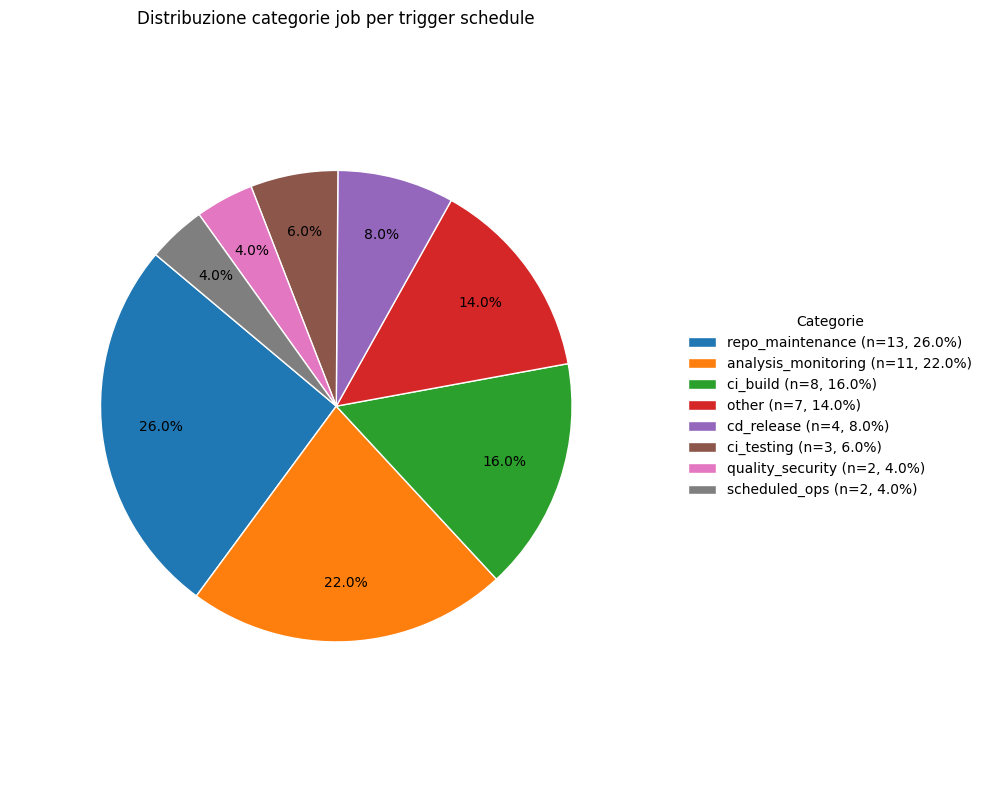

In [32]:
import matplotlib.pyplot as plt

def plot_job_category_pie(grouped_data, title="Distribuzione categorie job", legend_title="Categorie", figsize=(10, 8), startangle=140):
    labels = list(grouped_data.keys())
    values = [v["total"] for v in grouped_data.values()]
    total = sum(values)

    fig, ax = plt.subplots(figsize=figsize)

    wedges, _, _ = ax.pie(
        values,
        startangle=startangle,
        autopct=lambda p: f"{p:.1f}%",
        pctdistance=0.75,
        wedgeprops={"edgecolor": "white", "linewidth": 1}
    )

    legend_labels = [f"{lbl} (n={val}, {val/total*100:.1f}%)" for lbl, val in zip(labels, values)]
    ax.legend(
        wedges,
        legend_labels,
        title=legend_title,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False
    )

    ax.set_title(title)
    ax.axis("equal")
    plt.tight_layout()
    plt.show()

plot_job_category_pie(
    generic_grouped,
    title="Distribuzione categorie job per trigger schedule"
)

#### da qui possiamo osservare che per il 22% le azioni collegate ad uno schedule sono della categoria analisi e monitoring (servono a misurare e osservare il progetto nel tempo, ad esempio analisi periodiche, benchmark e generazione di metriche/report), mentre per il 26% si tratta di manutezione della repository (per mantenere la repository ordinata). Per il 16% invece vengono eseguite operazioni di build periodiche

#### analizziamo cosa succede nei push

{'ci_build': {'total': 66, 'items': {'build': 66}}, 'cd_release': {'total': 53, 'items': {'create-release': 5, 'deploy': 20, 'publish': 9, 'publish_docker_to_ecr': 3, 'release': 16}}, 'ci_testing': {'total': 42, 'items': {'pytest': 4, 'test': 38}}, 'quality_security': {'total': 33, 'items': {'check': 3, 'codespell': 2, 'conflicts': 3, 'lint': 15, 'pre-commit': 4, 'require-all-checks-to-pass': 3, 'size': 3}}, 'analysis_monitoring': {'total': 11, 'items': {'analyze': 11}}, 'other': {'total': 6, 'items': {'docs': 3, 'setup': 3}}, 'repo_maintenance': {'total': 4, 'items': {'migrate': 4}}, 'scheduled_ops': {'total': 3, 'items': {'notify': 3}}}


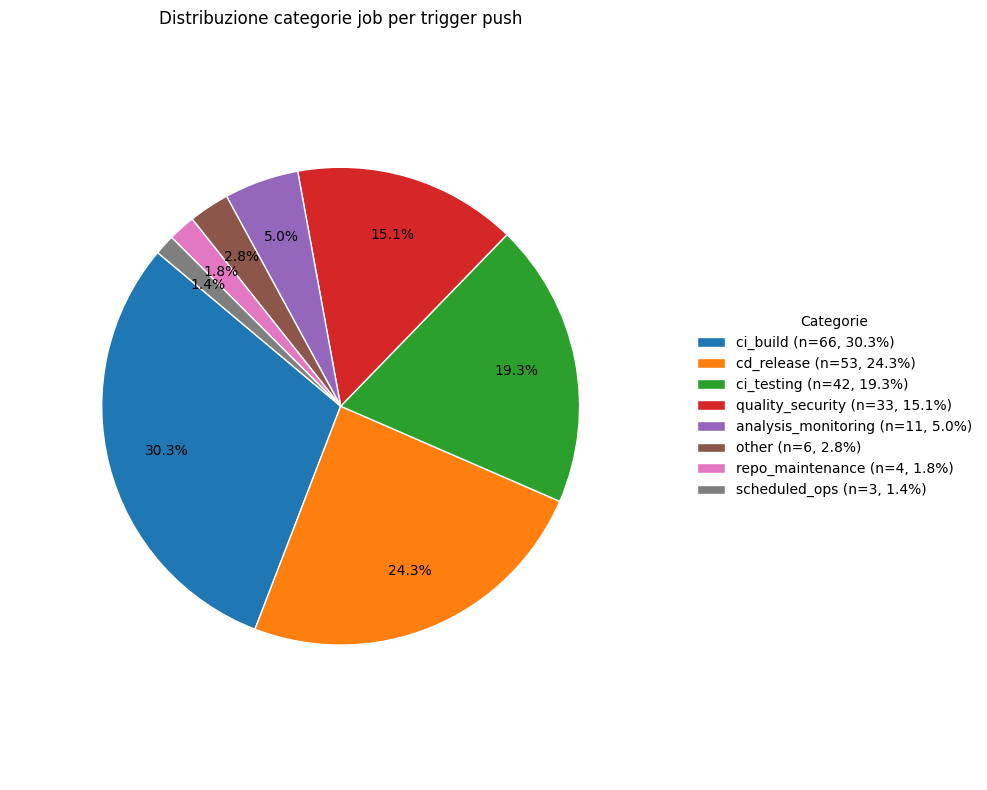

In [33]:
push_grouped = group_jobs_generic(result["push"]["most_associated_keywords"], extended_vocab=True)
print(push_grouped)

plot_job_category_pie(
    push_grouped,
    title="Distribuzione categorie job per trigger push"
)

#### possiamo notare che per quanto riguarda le azioni collegate al push in più del 75% delle volte sono correlate al build, release o testing, quindi sostanzialmente collegate a CI/CD

{'ci_testing': {'total': 45, 'items': {'pytest': 5, 'test': 37, 'unit-tests': 3}}, 'quality_security': {'total': 45, 'items': {'changed-files': 4, 'format': 5, 'lint': 17, 'mypy': 3, 'pre-commit': 4, 'pyright': 3, 'require-all-checks-to-pass': 3, 'type-check': 3, 'verify-version': 3}}, 'ci_build': {'total': 37, 'items': {'build': 37}}, 'analysis_monitoring': {'total': 17, 'items': {'analyze': 10, 'changes': 3, 'main': 4}}, 'cd_release': {'total': 6, 'items': {'block-prerelease': 3, 'deploy': 3}}, 'ai_native': {'total': 3, 'items': {'claude-review': 3}}, 'other': {'total': 3, 'items': {'setup': 3}}}


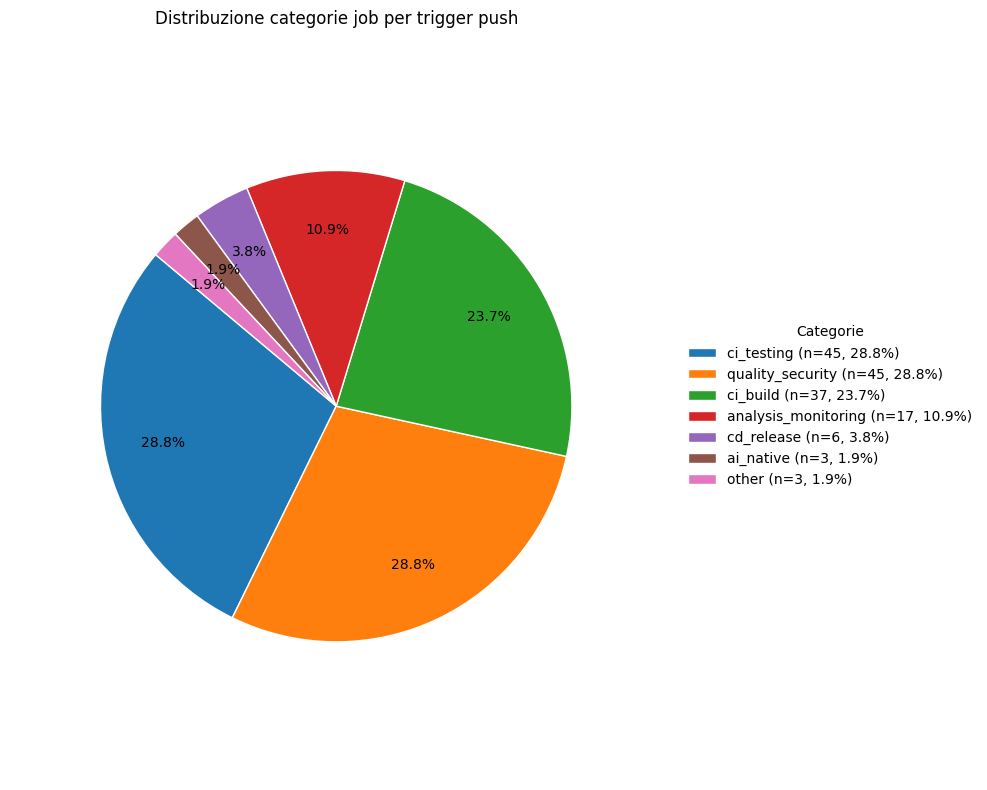

In [34]:
push_grouped = group_jobs_generic(result["pull_request"]["most_associated_keywords"], extended_vocab=True)
print(push_grouped)

plot_job_category_pie(
    push_grouped,
    title="Distribuzione categorie job per trigger push"
)

#### per quanto riguarda le pull requests, vi sono associate maggiormente operazioni di testing e build, ma spicca la categoria quality and security al 28%. inoltre notiamo un'inizio di adozione di job collegati all'IA, ieg: claude-review

{'cd_release': {'total': 53, 'items': {'check_release_name': 3, 'create-release': 5, 'deploy': 20, 'publish': 15, 'release': 10}}, 'ci_build': {'total': 39, 'items': {'build': 31, 'build-image': 4, 'docker': 4}}, 'ci_testing': {'total': 22, 'items': {'e2e': 3, 'e2e-app-store': 3, 'e2e-embed': 3, 'e2e-embed-react': 3, 'integration-test': 3, 'test': 7}}, 'other': {'total': 11, 'items': {'destroy': 2, 'merge': 4, 'required': 3, 'scale': 2}}, 'quality_security': {'total': 6, 'items': {'lint': 6}}, 'repo_maintenance': {'total': 3, 'items': {'stale': 3}}}


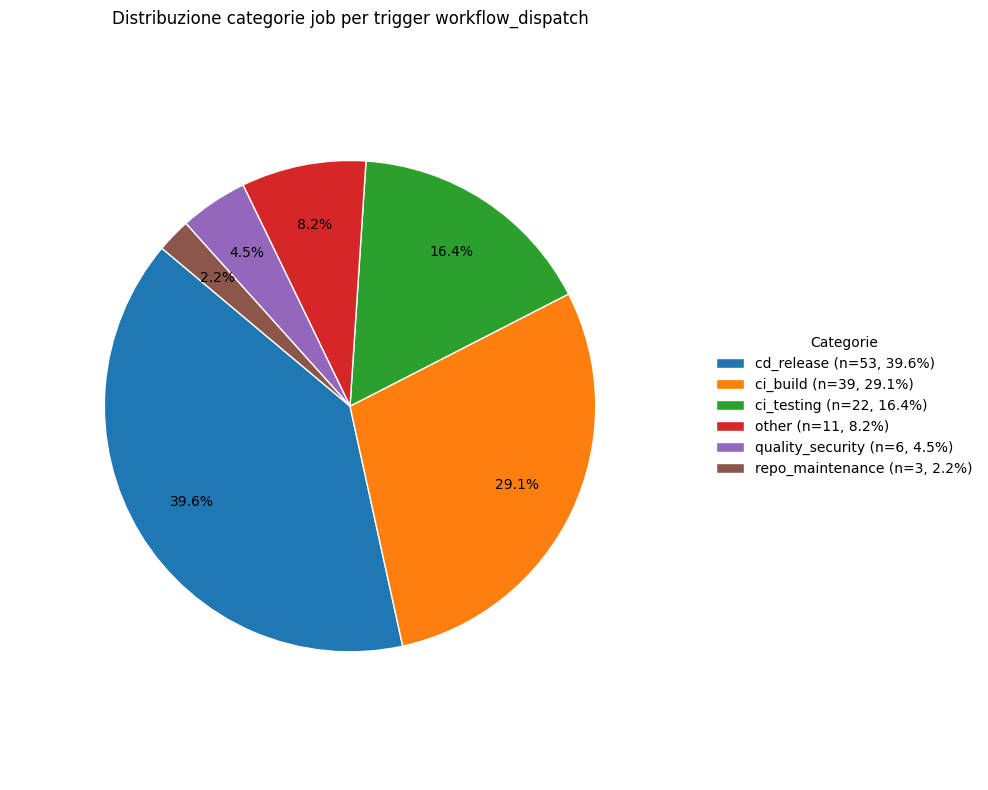

In [35]:
wdispatch_grouped = group_jobs_generic(result["workflow_dispatch"]["most_associated_keywords"], extended_vocab=True)
print(wdispatch_grouped)

plot_job_category_pie(
    wdispatch_grouped,
    title="Distribuzione categorie job per trigger workflow_dispatch"
)

La maggior parte dei workflow avviati manualmente sono i cd_release con anche una buona percentuale di build.

In [36]:
# controlliamo in che percentuale il manual labelling combacia con la classificazione automatica

df = pd.read_csv(LABELLED_DATASET_PATH)
comparison_df = df.dropna(subset=["SUGGESTED_WORKFLOW_TYPE", "workflow_type"]).copy()

def normalize_workflow_type(wt):
    # workflow_type è l1|l2 mentre SUGGESTED_WORKFLOW_TYPE è ['l1', 'l2'], quindi bisogna normalizzarli
    if isinstance(wt, str):
        return set(part.strip() for part in wt.split("|") if part.strip())
    return set()

def normalize_suggested_type(sst, row_idx="N/A"):
    # normalizzo la vecchia classificazione, quindi unknown diventa no_ops, lint e security vanno insieme 
    # in linty_security idem per deploy e release, e tutto quello che non è classificato diventa no_ops
    mapping = {
        "unknown": "no_ops", "other": "no_ops", "none": "no_ops",
        "lint": "lint_security", "security": "lint_security", "quality": "lint_security",
        "deploy": "deploy_release", "release": "deploy_release",
        "test": "test", "testing": "test",
        "build": "build", "ci_build": "build",
        "eval": "eval", "analysis": "eval", "monitoring": "eval"
    }

    if isinstance(sst, str):
        sst = sst.replace("[", "").replace("]", "").replace("'", "").replace('"', "")
        elements = [item.strip().lower() for item in sst.split(",") if item.strip()]
    elif isinstance(sst, list):
        elements = [str(item).strip().lower() for item in sst]
    else:
        return {"no_ops"}

    normalized_results = set()
    for item in elements:
        if item not in mapping:
            print(f"Parola non riconosciuta: '{item}' alla riga: {row_idx}")
        
        category = mapping.get(item, "no_ops")
        normalized_results.add(category)

    return normalized_results if normalized_results else {"no_ops"}


comparison_df["normalized_workflow_type"] = comparison_df["workflow_type"].apply(normalize_workflow_type)
comparison_df["normalized_suggested_type"] = comparison_df["SUGGESTED_WORKFLOW_TYPE"].apply(normalize_suggested_type)

# ora confronto
def compare_classifications(row):
    if row["normalized_workflow_type"] == row["normalized_suggested_type"]:
        return "match"
    elif row["normalized_workflow_type"].intersection(row["normalized_suggested_type"]):
        return "partial_match"
    else:
        return "mismatch"
    
comparison_df["classification_comparison"] = comparison_df.apply(compare_classifications, axis=1)
comparison_summary = comparison_df["classification_comparison"].value_counts(normalize=True) * 100
print(comparison_summary)

# analizziamo la distribuzione dei tipi di workflow nei casi di match per capire se il tutto è sbilanciato
match_df = comparison_df[comparison_df["classification_comparison"] == "match"]
match_type_distribution = match_df["normalized_workflow_type"].explode().value_counts(normalize=True) * 100
print(match_type_distribution)



classification_comparison
mismatch         48.0
match            36.0
partial_match    16.0
Name: proportion, dtype: float64
normalized_workflow_type
no_ops            40.0
build             20.0
test              20.0
lint_security     15.0
deploy_release     5.0
Name: proportion, dtype: float64


In [79]:
SYSTEM_PROMPT = """You classify GitHub Actions jobs inside <yaml> tags.
Valid labels:
- build
- test
- deploy_release
- lint_security
- eval
- no_ops
Definitions:
- build:
  Compiling code, packaging artifacts, building containers, generating binaries,
  publishing build assets, dependency update automation.
  IMPORTANT:
  Installing dependencies ONLY to execute tests is NOT build.
- test:
  Running tests, validation suites, CI checks, tox, pytest, jest, integration tests,
  artifact verification, runtime validation.
  IMPORTANT:
  Environment setup or dependency installation required for tests
  still counts ONLY as test.
- deploy_release:
  Releasing, publishing, pushing images/artifacts, signing, GitHub Releases.
- lint_security:
  Linting, formatting checks, static analysis, policy checks, security scans,
  dependency vulnerability scans.
- eval:
  Benchmarks, model evaluation, scoring, performance evaluation.
- no_ops:
  No meaningful execution.
Rules:
1. Output EXACTLY:
[CATEGORY]
Reason: <short reason>
2. Multiple labels:
[build | test]
3. Use ONLY valid labels.
4. Reason <= 12 words.
5. No markdown or extra text.
6. Classify by PRIMARY INTENT, not setup commands.
7. Dependency installation for testing does NOT imply build.
8. Prefer the most specific label.
9. Use multiple labels ONLY when the job clearly does both things.
Examples:
<yaml>
steps:
  - run: npm ci
  - run: npm test
</yaml>
[test]
Reason: Installs dependencies and runs tests.
<yaml>
steps:
  - run: pip install tox
  - run: tox
</yaml>
[test]
Reason: Executes automated test suite.
<yaml>
steps:
  - run: docker build -t app .
</yaml>
[build]
Reason: Builds Docker image.
<yaml>
steps:
  - run: pytest
  - run: coverage xml
</yaml>
[test]
Reason: Runs validation and coverage checks.
<yaml>
steps:
  - uses: docker/build-push-action@v5
    with:
      push: true
</yaml>
[deploy_release]
Reason: Pushes container image.
<yaml>
steps:
  - run: ruff check .
  - run: bandit -r .
</yaml>
[lint_security]
Reason: Runs linting and security scans.
<yaml>
steps:
  - run: docker build -t app .
  - run: pytest
  - uses: docker/build-push-action@v5
    with:
      push: true
</yaml>
[build | test | deploy_release]
Reason: Builds image, runs tests, and pushes artifact.
<yaml>
steps:
  - run: ruff check .
  - run: docker build -t app .
  - run: docker push app
</yaml>
[lint_security | build | deploy_release]
Reason: Lints code, builds and publishes container.
<yaml>
steps:
  - run: npm run lint
  - run: npm test
</yaml>
[lint_security | test]
Reason: Runs linting checks and test suite.
"""

build_prompt = lambda yaml_content: (
    f"<yaml>\n{yaml_content}\n</yaml>"
)

In [80]:
import lmstudio as lms

LM_STUDIO_API_ENDPOINT = "127.0.0.1:1234"
MODEL_PATH = "gemma-3-27b-it"
TEMPERATURE = 0.1
TOP_P = 0.8
TOP_K = 40

client = lms.Client(LM_STUDIO_API_ENDPOINT)
model = client.llm.model(MODEL_PATH)

def classify_job_with_llm(yaml_content):
    chat = lms.Chat(SYSTEM_PROMPT)
    
    chat.add_user_message(build_prompt(yaml_content))
    
    response = model.respond(chat, config={
        "temperature": TEMPERATURE,
        "top_p": TOP_P,
        "top_k": TOP_K,
    })
    
    return response.content.strip()

In [20]:
import anthropic
import os

api_key = ""
claude_client = anthropic.Anthropic(api_key=api_key)

CLAUDE_SYSTEM_PROMPT = """You are an Expert DevOps & CI/CD Architect.
Your task is to categorize the provided GitHub Actions job (wrapped in <yaml> tags) into one or more specific categories.

<categories>
- build: Compiling code, updating dependencies (pip/npm), building Docker images.
- test: Running test suites (pytest, jest), verifying artifacts.
- deploy_release: Pushing images (push: true), signing (cosign), GitHub Releases.
- lint_security: Linting, path/policy checks, vulnerability scans, dependency upgrades.
- eval: Model evaluation/benchmarking.
- no_ops: Jobs with no functional impact.
</categories>

<constraints>
1. Output STRICTLY in this exact format: [CATEGORY] \n Reason: [Reason on why the job belongs to the category/categories]
2. If multiple categories apply, separate them with " | " (e.g., [build | test]).
3. The "Reason" MUST be extremely concise (under 20 words).
4. ABSOLUTELY NO conversational filler, greetings, or internal thinking. Start your response directly with the bracketed category.
</constraints>

<examples>
<example>
<yaml>
steps:
  - uses: actions/checkout@v3
  - run: npm ci
  - run: npm test
</yaml>
<output>
[build | test]
Reason: Installs npm dependencies (build) and runs automated test suite (test).
</output>
</example>
</examples>"""

build_claude_prompt = lambda yaml_content: f"<yaml>\n{yaml_content}\n</yaml>"
CLAUDE_TEMPERATURE = 0.2
CLAUDE_MODEL = "claude-haiku-4-5-20251001"

def classify_job_with_llm(yaml_content):
    response = claude_client.messages.create(
        model=CLAUDE_MODEL,
        max_tokens=1024,
        temperature=CLAUDE_TEMPERATURE,
        system=CLAUDE_SYSTEM_PROMPT,
        messages=[
            {
                "role": "user", 
                "content": build_claude_prompt(yaml_content)
            }
        ]
    )
    
    return response.content[0].text.strip()

In [81]:
_test = """{runs-on: ubuntu-latest, steps: [{name: Checkout repository, uses: actions/checkout@v3},
    {name: 'Set up Python ${{ matrix.python-version }}', uses: actions/setup-python@v4,
      with: {cache: pip, python-version: '${{ matrix.python-version == ''3.12'' &&
          ''3.12.3'' || matrix.python-version }}'}}, {name: Check Python Version,
      run: python --version}, {name: Install dependencies, run: 'python -m pip install
        --upgrade pip

        pip install tox==4.15.0 poetry

        '}, {env: {OPENAI_API_KEY: '${{ secrets.OPENAI_API_KEY }}'}, name: Run tox,
      run: tox}], strategy: {matrix: {python-version: ['3.10', '3.11', '3.12']}}}"""


classify_job_with_llm(_test)

'[test]\nReason: Installs dependencies and runs tests with tox.'

In [82]:
# Eseguo la classificazione con LLM sui primi 100 job per testarne le metriche
__run = True

if __run:
    extracted_workflow_types_df = pd.read_csv(LABELLED_DATASET_PATH)
    cnt = 0

    for idx, row in extracted_workflow_types_df.iterrows():
        if cnt >= 100:
            break
        try:
            yaml_content = row["job"]
            classification = classify_job_with_llm(yaml_content)
            label, motivazione = classification.split("\n")
            label = label.replace(' ', '')
            motivazione = motivazione.split(":")[1].strip()
            workflow_type = f"[{row['workflow_type'].replace(' ', '')}]"

            equals = "SI" if label == workflow_type else "NO"

            print(f"Riga {idx}: LLM label: {label}\nLLM: {motivazione}\nETICHETTA : {workflow_type}\nUGUALI? : {equals}\n\n")

            extracted_workflow_types_df.at[idx, "LLM_LABEL"] = label
            extracted_workflow_types_df.at[idx, "LLM_REASON"] = motivazione
            cnt += 1
        except Exception as e:
            break

    # salvo il dataframe parziale
    extracted_workflow_types_df.head(100).to_csv(PARTIAL_CLAUDE_LABELLED_DATASET_PATH, index=False)
else:
    extracted_workflow_types_df = pd.read_csv(PARTIAL_CLAUDE_LABELLED_DATASET_PATH)
    

Riga 0: LLM label: [test]
LLM: Installs dependencies and runs tests with tox.
ETICHETTA : [test]
UGUALI? : SI


Riga 1: LLM label: [lint_security]
LLM: Runs pre-commit hooks for code formatting and linting.
ETICHETTA : [lint_security]
UGUALI? : SI


Riga 2: LLM label: [no_ops]
LLM: No meaningful execution or code changes occur.
ETICHETTA : [lint_security]
UGUALI? : NO


Riga 3: LLM label: [build]
LLM: Builds and packages Python distribution artifacts.
ETICHETTA : [build]
UGUALI? : SI


Riga 4: LLM label: [deploy_release]
LLM: Publishes packages to PyPI.
ETICHETTA : [deploy_release]
UGUALI? : SI


Riga 5: LLM label: [build|test]
LLM: Compiles code and runs tests.
ETICHETTA : [test]
UGUALI? : NO


Riga 6: LLM label: [no_ops]
LLM: Job performs no meaningful execution.
ETICHETTA : [no_ops]
UGUALI? : SI


Riga 7: LLM label: [no_ops]
LLM: Job performs no meaningful execution.
ETICHETTA : [no_ops]
UGUALI? : SI


Riga 8: LLM label: [lint_security|test]
LLM: Lints code and runs client tests.
ET

In [83]:
# controllo in che percetntuale le label coincidono
comparison_df = extracted_workflow_types_df.dropna(subset=["LLM_LABEL", "workflow_type"]).copy()

def compare(row, label_name: str = "LLM_LABEL"):
    if row[label_name].strip("[]") == row["workflow_type"].strip():
        return "SI"
    elif set(row[label_name].strip("[]").split("|")).intersection(set(row["workflow_type"].split("|"))):
        return "PARZIALE"
    else:
        return "NO"
    

comparison_df["classification_comparison"] = comparison_df.apply(compare, axis=1)
comparison_summary = comparison_df["classification_comparison"].value_counts(normalize=True) * 100
print(comparison_summary)

classification_comparison
SI          65.0
PARZIALE    18.0
NO          17.0
Name: proportion, dtype: float64


In [66]:
# self refinementtttttttt fase 2: FEEDBACK PROMPT


FEEDBACK_SYSTEM_PROMPT = """You are a strict CI/CD classification auditor. You will receive a GitHub Actions YAML job and a model-provided classification.

Categories:
- build: Compiling code, updating dependencies (pip/npm), building Docker images.
- test: Running test suites (pytest, jest), verifying artifacts.
- deploy_release: Pushing images, signing, GitHub Releases.
- lint_security: Linting, path/policy checks, vulnerability scans, dependency upgrades.
- eval: Model evaluation or benchmarking.
- no_ops: Jobs with no functional impact.

Your task: evaluate the classification and provide structured feedback.

Check for:
1. FALSE POSITIVES: categories wrongly assigned.
2. FALSE NEGATIVES: categories that should apply but are missing.
3. REASONING ERRORS: reason contradicts YAML content.

Output format:
- If correct: [STOP]
- If issues exist:
  ISSUE: [specific problem]
  SUGGESTION: [correct classification and concise rationale]

Rules:
- Be extremely concise.
- Critique only; do NOT generate a new classification.
- Always output [STOP] if acceptable."""

# self refinement fase 3: REFINEMENT PROMPT

REFINE_SYSTEM_PROMPT = """You are an Expert DevOps & CI/CD Architect. You previously classified a GitHub Actions job. A critic provided feedback on your classification.

Categories:
- build: Compiling code, updating dependencies (pip/npm), building Docker images.
- test: Running test suites (pytest, jest), verifying artifacts.
- deploy_release: Pushing images, signing, GitHub Releases.
- lint_security: Linting, path/policy checks, vulnerability scans, dependency upgrades.
- eval: Model evaluation or benchmarking.
- no_ops: Jobs with no functional impact.

Constraints:
1. Output STRICTLY as: [CATEGORY] 
   Reason: [concise reason]
2. Multiple categories separated by " | " (e.g., [build | test]).
3. Reason must be concise, under 20 words.
4. No filler; start directly with the bracketed category.
5. Correct all issues identified in the feedback."""


def build_feedback_prompt(
    yaml_content: str,
    current_classification: str
) -> str:
    return (
        f"<yaml>\n{yaml_content}\n</yaml>\n\n"
        f"<prediction>\n{current_classification}\n</prediction>"
    )


def build_refine_prompt(
    yaml_content: str,
    current_classification: str,
    feedback: str
) -> str:
    return (
        f"<yaml>\n{yaml_content}\n</yaml>\n\n"
        f"<current>\n{current_classification}\n</current>\n\n"
        f"<feedback>\n{feedback}\n</feedback>"
    )


MAX_ITERATIONS = 2  # https://arxiv.org/pdf/2303.17651 l'apice si raggiunge dopo max 2 iterazioni

VALID_LABELS = {
    "build",
    "test",
    "deploy_release",
    "lint_security",
    "eval",
    "no_ops"
}


def normalize_classification(text: str) -> str:
    import re

    match = re.search(r"\[(.*?)\]", text)
    if not match:
        return text.strip()

    raw_labels = match.group(1)

    labels = [
        label.strip()
        for part in raw_labels.split("|")
        for label in [part.strip()]
        if label.strip() in VALID_LABELS
    ]

    labels = sorted(set(labels))

    reason_match = re.search(r"Reason:\s*(.*)", text, re.IGNORECASE)
    reason = reason_match.group(1).strip() if reason_match else ""

    return f"[{' | '.join(labels)}]\nReason: {reason}"


cnt = 0

def classify_with_self_refine(row) -> dict:
    current_classification = normalize_classification(row['LLM_LABEL'])
    history = []
    global cnt
    cnt += 1

    print(f"\n\nrow number {cnt}\n\n")

    yaml_content = row['job']

    effective_iterations = (
        1 if current_classification.count("|") == 0
        else MAX_ITERATIONS
    )

    for i in range(effective_iterations):

        feedback_chat = lms.Chat(FEEDBACK_SYSTEM_PROMPT)

        feedback_chat.add_user_message(
            build_feedback_prompt(
                yaml_content,
                current_classification
            )
        )

        feedback_response = model.respond(
            feedback_chat,
            config={
                "temperature": 0.0,
                "top_p": 0.8,
                "top_k": 40,
            }
        )

        feedback = feedback_response.content.strip()

        print(f"Feedback all'iterazione {i+1} : {feedback}")

        history.append((current_classification, feedback))

        if "[STOP]" in feedback:
            print(f"Dopo {i} iterazioni di refinement l'llm è convinto che è correto")
            break

        refine_chat = lms.Chat(REFINE_SYSTEM_PROMPT)

        refine_chat.add_user_message(
            build_refine_prompt(
                yaml_content,
                current_classification,
                feedback
            )
        )

        refine_response = model.respond(
            refine_chat,
            config={
                "temperature": 0.05,
                "top_p": 0.8,
                "top_k": 40,
            }
        )

        current_classification = normalize_classification(
            refine_response.content.strip()
        )

    return {
        "final": current_classification,
        "iterations": len(history),
        "history": history,
    }

In [67]:
# carico il dataset con le label generate da LLM (prendo solo i primi 100 per fare refinement)
c_df = extracted_workflow_types_df.head(100)

for idx, row in c_df.iterrows():
    result_for_job = classify_with_self_refine(row)

    # modifico il csv
    c_df.at[idx, "REFINED_LLM_LABEL"] = result_for_job["final"]
    c_df.at[idx, "REFINEMENT_ITERATIONS"] = result_for_job["iterations"]
    c_df.at[idx, "REFINEMENT_HISTORY"] = str(result_for_job["history"])

# salvo il dataset con le label raffinate
c_df.to_csv(PARTIAL_CLAUDE_LABELLED_DATASET_PATH + "_refined.csv", index=False)



row number 1


Feedback all'iterazione 1 : ISSUE: Misclassification - job focuses on dependency management and running tox, not tests.
SUGGESTION: [build] Dependency installation and tool setup are build steps. Tox can be part of testing but isn't inherently a test itself here.


row number 2


Feedback all'iterazione 1 : ISSUE: Missing category.
SUGGESTION: [no_ops] - Job only checks out code and sets up Python, then runs pre-commit hooks which are primarily linting/formatting but don't deploy or build anything. It doesn’t have functional impact beyond code style.


row number 3


Feedback all'iterazione 1 : [STOP]
Dopo 0 iterazioni di refinement l'llm è convinto che è correto


row number 4


Feedback all'iterazione 1 : ISSUE: Missing category.
SUGGESTION: [no_ops] The job prepares a package but does not deploy or release it. It only builds artifacts.

[STOP]
Dopo 0 iterazioni di refinement l'llm è convinto che è correto


row number 5


Feedback all'iterazione 1 : [STOP]
Dopo 0 it

In [69]:
# rimuovo allucinazioni in REFINED_LLM_LABEL
__remove_allucinazioni = True

if __remove_allucinazioni:
    for idx, row in c_df.iterrows():
        label = row["REFINED_LLM_LABEL"]
        # prendo solo quello tra le quadre
        n_label = re.findall(r"\[([^\]]+)\]", label)
        if n_label:
            c_df.at[idx, "REFINED_LLM_LABEL"] = n_label[0]
        else:
            c_df.at[idx, "REFINED_LLM_LABEL"] = label

    # salvo
    c_df.to_csv(PARTIAL_CLAUDE_LABELLED_DATASET_PATH + "_refined.csv", index=False)
else:
    pass


# controllo in che percetntuale le label coincidono
refine_cmp = c_df.dropna(subset=["REFINED_LLM_LABEL", "workflow_type"]).copy()
refine_cmp["classification_comparison"] = refine_cmp.apply(compare, axis=1, label_name="REFINED_LLM_LABEL")

# percentuali
refine_summary = refine_cmp["classification_comparison"].value_counts(normalize=True) * 100
print(refine_summary)

classification_comparison
NO          56.0
SI          40.0
PARZIALE     4.0
Name: proportion, dtype: float64


In [42]:
# stampo il contenuto del job, la label workflow_type e la label raffinata per capire meglio i casi di mismatch
mismatch_df = refine_cmp[refine_cmp["classification_comparison"] == "NO"]
for idx, row in mismatch_df.iterrows():
    print(f"Riga {row['file_hash']}:\nJob name: {row['job_name']}\nJob YAML:\n{row['job']}\nLabel originale: {row['workflow_type']}\nLabel raffinata: {row['REFINED_LLM_LABEL']}\n\n")

Riga 953a30775359908a4e420d0532b35d3c3517736afd745af591a8aa82e695ab36:
Job name: mark-stale-issues
Job YAML:
{runs-on: ubuntu-latest, steps: [{name: Mark stale issues, uses: actions/stale@v4,
      with: {days-before-stale: 60, stale-issue-message: This issue has been automatically
          marked as stale because it has not had recent activity. It will be closed
          if no further activity occurs.}}]}

Label originale: lint_security
Label raffinata: no_ops


Riga 5147a4948766bb4b952be4dd6b74f2a4acba2daa054479d6ee09dc002c0c5952:
Job name: build-and-sign-tauri
Job YAML:
{env: {ORT_LIB_LOCATION: '${{ github.workspace }}/lib/${{ matrix.target }}/onnxruntime'},
  runs-on: '${{ matrix.name }}', steps: [{if: matrix.name == 'ubuntu-20.04', uses: pierotofy/set-swap-space@v1.0,
      with: {swap-size-gb: 10}}, {name: Checkout code, uses: actions/checkout@v4,
      with: {token: '${{ secrets.GITHUB_TOKEN }}'}}, {name: Create LFS file list,
      run: git lfs ls-files --long | cut -d ' ' -f

In [ ]:
# dato che i risultati senza refinement sono ottimi procedo nel fare il labeling con LLM su tutto il dataset

extracted_workflow_types_df = pd.read_csv(LABELLED_DATASET_PATH)

import re
import time

for idx, row in extracted_workflow_types_df.iterrows():
    try:
        yaml_content = row["job"]
        raw = classify_job_with_llm(yaml_content)

        match = re.search(r'\[([^\]]+)\]', raw)
        if match:
            label = match.group(1).strip().replace(' ', '')
        else:
            label = "UNKNOWN"
            print(f"Riga {idx}: nessuna label trovata in: {repr(raw)}")

        motivazione = raw.replace(match.group(0), '').strip() if match else ""

        print(f"Riga {idx}: label={label} | motivazione={motivazione[:80]}...")
        extracted_workflow_types_df.at[idx, "LLM_LABEL"] = label
        extracted_workflow_types_df.at[idx, "LLM_MOTIVAZIONE"] = motivazione

    except Exception as e:
        print(f"ERRORE riga {idx}: {type(e).__name__}: {e}")
        time.sleep(5)
        continue

    if idx % 50 == 0:
        extracted_workflow_types_df.to_csv("COMPLETE_extracted_workflow_types_with_llm_labels.csv", index=False)
        print(f"Checkpoint salvato alla riga {idx}")

extracted_workflow_types_df.to_csv("V2_COMPLETE_extracted_workflow_types_with_llm_labels.csv", index=False)

Riga 0: label=test | motivazione=Reason: Runs test suite (tox)....
Checkpoint salvato alla riga 0
Riga 1: label=lint_security | motivazione=Reason: Lints and formats code....
Riga 2: label=no_ops | motivazione=Reason: No meaningful execution....
Riga 3: label=build | motivazione=Reason: Builds and packages code....
Riga 4: label=deploy_release | motivazione=Reason: Publishes package to PyPI....
Riga 5: label=test | motivazione=Reason: Runs Rust tests and linting....
Riga 6: label=no_ops | motivazione=Reason: No meaningful execution....
Riga 7: label=no_ops | motivazione=Reason: No meaningful execution....
Riga 8: label=test | motivazione=Reason: Runs tests and linting....
Riga 9: label=deploy_release | motivazione=Reason: Uploads release assets....
Riga 10: label=build | motivazione=Reason: Builds container image....
Riga 11: label=lint_security | motivazione=Reason: Validates Helm chart security....
Riga 12: label=no_ops | motivazione=Reason: No meaningful execution....
Riga 13: label

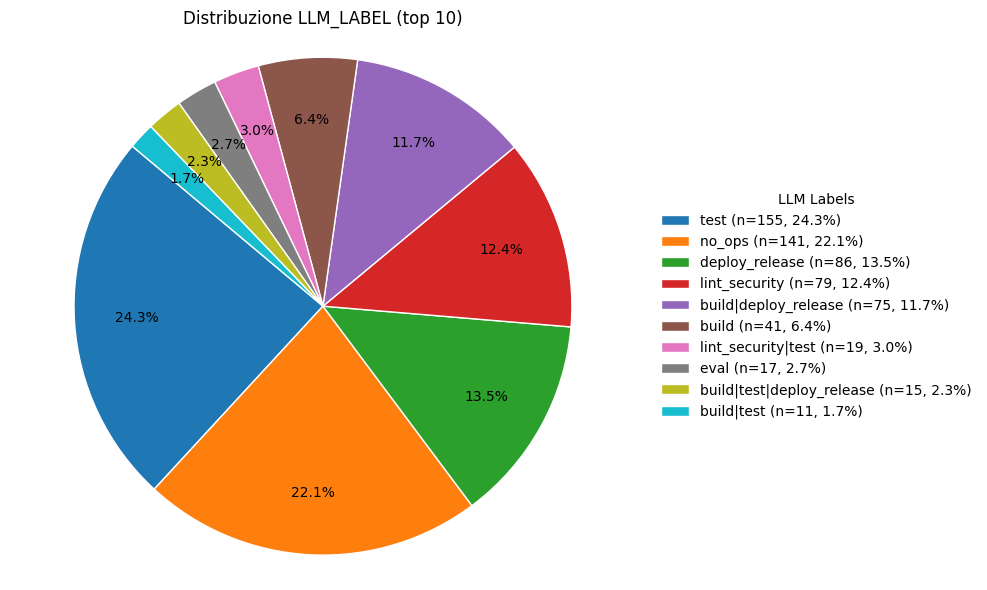

In [10]:
import matplotlib.pyplot as plt
df_nuvo = pd.read_csv("/Users/giuseppepiosorrentino/awesome-ai-agents-cicd-extract/gigawork/V2_COMPLETE_extracted_workflow_types_with_llm_labels.csv")
new_label_counts = df_nuvo["LLM_LABEL"].value_counts().head(10)
label_counts = new_label_counts
labels = label_counts.index.tolist()
values = label_counts.values.tolist()
total = sum(values)

figsize = (10, 6)
startangle = 140
legend_title = "LLM Labels"
title = "Distribuzione LLM_LABEL (top 10)"

fig, ax = plt.subplots(figsize=figsize)
wedges, _, _ = ax.pie(
    values,
    startangle=startangle,
    autopct=lambda p: f"{p:.1f}%",
    pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 1}
 )
legend_labels = [f"{lbl} (n={val}, {val/total*100:.1f}%)" for lbl, val in zip(labels, values)]
ax.legend(
    wedges,
    legend_labels,
    title=legend_title,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
 )
ax.set_title(title)
ax.axis("equal")
plt.tight_layout()
plt.show()

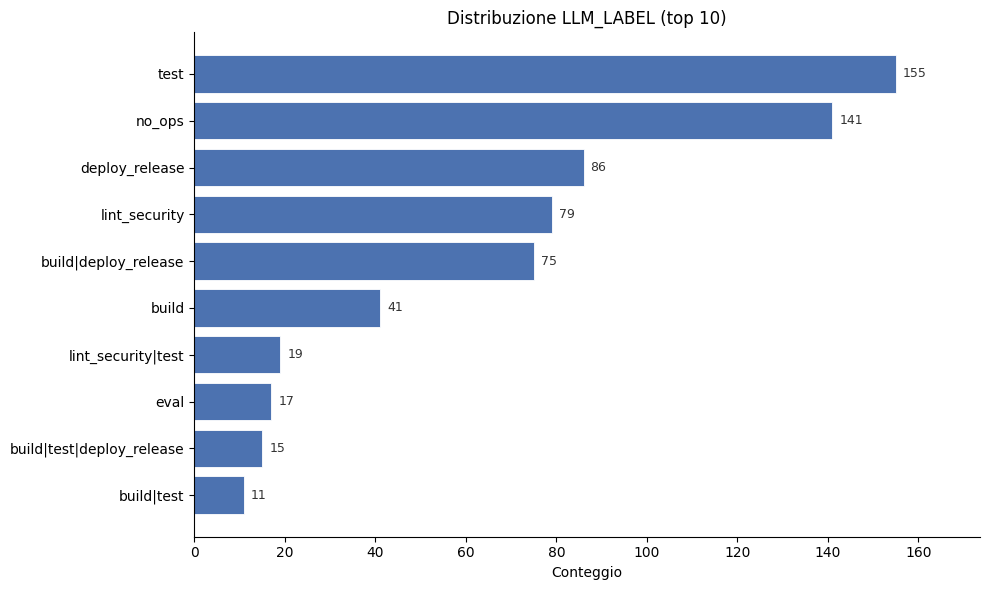

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mticker

df_nuvo = pd.read_csv("/Users/giuseppepiosorrentino/awesome-ai-agents-cicd-extract/gigawork/V2_COMPLETE_extracted_workflow_types_with_llm_labels.csv")
label_counts = df_nuvo["LLM_LABEL"].value_counts().head(10)

labels = label_counts.index.tolist()
values = label_counts.values.tolist()

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(labels[::-1], values[::-1], color="#4C72B0", edgecolor="white", linewidth=0.6)
ax.set_title("Distribuzione LLM_LABEL (top 10)")
ax.set_xlabel("Conteggio")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.spines[["top", "right"]].set_visible(False)

for bar, val in zip(bars, values[::-1]):
    ax.text(bar.get_width() + max(values) * 0.01, bar.get_y() + bar.get_height() / 2, str(val),
            va="center", ha="left", fontsize=9, color="#333")

ax.set_xlim(0, max(values) * 1.12)
plt.tight_layout()
plt.show()

Ne emerge che l'operazione che più viene svolta in solitudine è quella di test, generalmente, tutte le cateogire da noi individuate sono "isolate" tranne la build deploy che dimostra una certa sincronia anche insieme

In [11]:
#adesso vediamo in generale quante volte compare ogni singola label
#praticamente per ogni categoria conto quante volte compare in ogni riga, anche quando è insieme ad altre categorie

from collections import Counter
label_counter = Counter()
for labels in df_nuvo["LLM_LABEL"].dropna():
    for label in labels.split("|"):
        label_counter[label.strip()] += 1
print(label_counter.most_common())


[('test', 223), ('deploy_release', 184), ('build', 154), ('no_ops', 142), ('lint_security', 120), ('eval', 26)]


In [16]:
#ora vediamo la percentuale di quante volte compare ogni label da sola rispetto a quando compare insieme ad altre label, per capire se ci sono label che tendono ad essere più "solitarie" o più "compagne"
solo_counter = Counter()
compagno_counter = Counter()
for labels in df_nuvo["LLM_LABEL"].dropna():
    label_list = [label.strip() for label in labels.split("|")]
    if len(label_list) == 1:
        solo_counter[label_list[0]] += 1
    else:
        for label in label_list:
            compagno_counter[label] += 1
print("Label che compaiono da sole più spesso:")
print(solo_counter)
print("\nLabel che compaiono più spesso insieme ad altre label:")
print(compagno_counter)

percentuale_solo = {label: (solo_counter[label] / (solo_counter[label] + compagno_counter[label])) * 100 for label in label_counter}
print("\nPercentuale di comparsa da sola per ogni label:")
for label, percent in percentuale_solo.items():
    print(f"{label}: {percent:.1f}%")


Label che compaiono da sole più spesso:
Counter({'test': 155, 'no_ops': 141, 'deploy_release': 86, 'lint_security': 79, 'build': 41, 'eval': 17})

Label che compaiono più spesso insieme ad altre label:
Counter({'build': 113, 'deploy_release': 98, 'test': 68, 'lint_security': 41, 'eval': 9, 'no_ops': 1})

Percentuale di comparsa da sola per ogni label:
test: 69.5%
lint_security: 65.8%
no_ops: 99.3%
build: 26.6%
deploy_release: 46.7%
eval: 65.4%


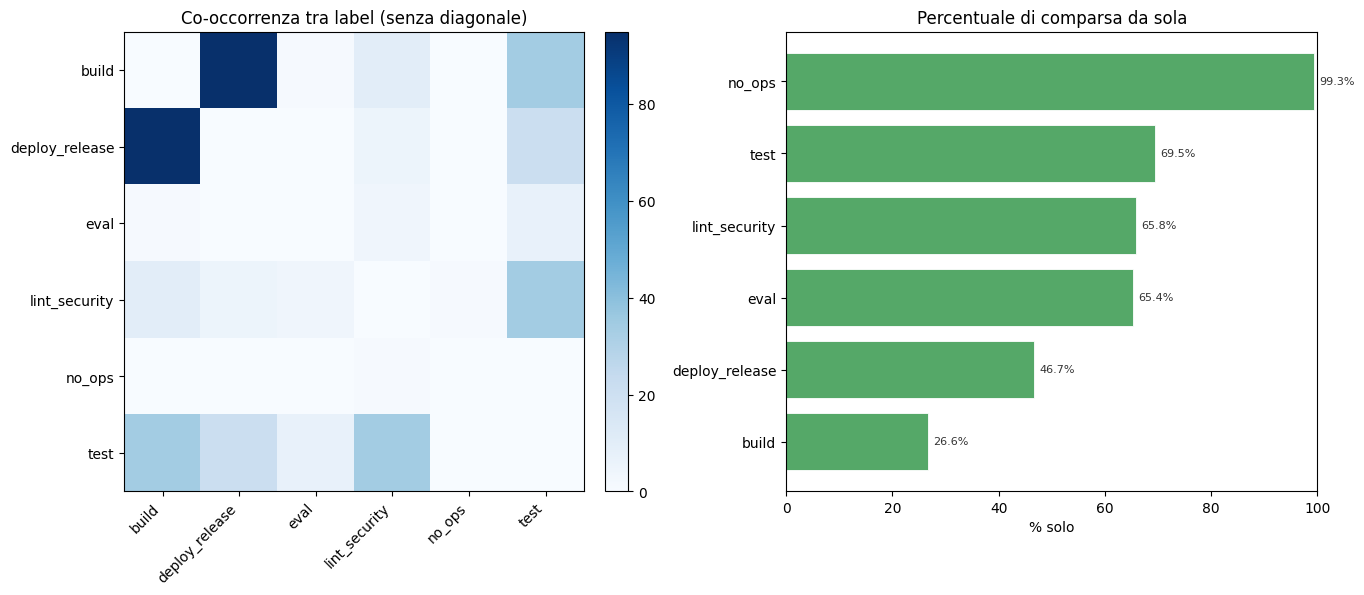

Co-occorrenza piu forte: build + deploy_release (n=95)
Label piu spesso da sola: ('no_ops', 99.29577464788733)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Co-occorrenze tra label e quanto spesso ogni label appare da sola
label_lists = (
    df_nuvo["LLM_LABEL"]
    .dropna()
    .apply(lambda s: [lbl.strip() for lbl in s.split("|") if lbl.strip()])
)

all_labels = sorted({lbl for labels in label_lists for lbl in labels})
# Aggiungo "alone" come pseudo-label
all_labels_with_alone = all_labels + ["alone"]
label_index = {lbl: i for i, lbl in enumerate(all_labels_with_alone)}

# Matrice di dimensione (n_labels + 1) x (n_labels + 1)
co_mat = np.zeros((len(all_labels_with_alone), len(all_labels_with_alone)), dtype=int)
solo_counts = {lbl: 0 for lbl in all_labels}
total_counts = {lbl: 0 for lbl in all_labels}

for labels in label_lists:
    uniq = sorted(set(labels))
    for lbl in uniq:
        total_counts[lbl] += 1
    
    if len(uniq) == 1:
        # Se appare solo, incremento solo_counts
        solo_counts[uniq[0]] += 1
        # E incremento la co-occorrenza con "alone"
        ia = label_index[uniq[0]]
        i_alone = label_index["alone"]
        co_mat[ia, i_alone] += 1
        co_mat[i_alone, ia] += 1
    else:
        # Coppia tra label effettive
        for i, a in enumerate(uniq):
            for b in uniq[i + 1:]:
                ia, ib = label_index[a], label_index[b]
                co_mat[ia, ib] += 1
                co_mat[ib, ia] += 1

# Maschero la diagonale: non è informativa
np.fill_diagonal(co_mat, 0)

# Trova la coppia piu frequente (escludendo "alone")
co_mat_no_alone = co_mat[:-1, :-1]
max_idx = np.unravel_index(np.argmax(co_mat_no_alone), co_mat_no_alone.shape)
max_pair = (all_labels[max_idx[0]], all_labels[max_idx[1]])
max_val = co_mat_no_alone[max_idx]

fig, ax = plt.subplots(figsize=(10, 9))

# Heatmap co-occorrenze con "alone"
im = ax.imshow(co_mat, cmap="Blues")
ax.set_title("Co-occorrenza tra label (con 'alone')")
ax.set_xticks(range(len(all_labels_with_alone)))
ax.set_yticks(range(len(all_labels_with_alone)))
ax.set_xticklabels(all_labels_with_alone, rotation=45, ha="right")
ax.set_yticklabels(all_labels_with_alone)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Aggiungi valori nella matrice
for i in range(len(all_labels_with_alone)):
    for j in range(len(all_labels_with_alone)):
        text = ax.text(j, i, int(co_mat[i, j]),
                       ha="center", va="center", color="black", fontsize=8)

plt.tight_layout()
plt.show()

print(f"Co-occorrenza piu forte: {max_pair[0]} + {max_pair[1]} (n={max_val})")
print(f"\nOccorrenze da sole per ogni label:")
for lbl in all_labels:
    print(f"  {lbl}: {solo_counts[lbl]}")
